# 03 · Preprocesamiento y reducción de dimensionalidad (Fase 3)

1. Codificación de variables categóricas
2. Escalado de variables numéricas
3. Reducción de dimensionalidad con PCA y visualización

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.decomposition import PCA
from src.utils import PROCESSED, guardar_fig

sns.set_theme(style="whitegrid")
df = pd.read_csv(PROCESSED / "taxis_clean.csv")

log_cols = ["distance", "fare", "tip", "total", "duration_min"]   # sesgadas
num_cols = ["passengers", "hour", "weekday"]
cat_cols = ["color", "payment", "pickup_borough", "dropoff_borough"]
bin_cols = ["airport", "has_toll", "zone_missing", "payment_missing", "suspicious_trip"]

X = df[log_cols + num_cols + cat_cols + bin_cols].copy()
X[bin_cols] = X[bin_cols].astype(int)
print(X.shape)

(6433, 17)


## 1. Codificación de variables categóricas

**One-Hot Encoding** para color, pago y municipios: son nominales (sin orden) y tienen pocas categorías. Las zonas (~200 valores) se dejan por fuera porque One-Hot generaría ~400 columnas casi vacías; su información queda representada por el municipio.

In [2]:
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
cat_enc = pd.DataFrame(ohe.fit_transform(X[cat_cols]), columns=ohe.get_feature_names_out(cat_cols))
print("Columnas generadas:", cat_enc.shape[1])
cat_enc.head()

Columnas generadas: 16


,color_green,color_yellow,payment_cash,payment_credit card,payment_desconocido,pickup_borough_Bronx,pickup_borough_Brooklyn,pickup_borough_Desconocido,pickup_borough_Manhattan,pickup_borough_Queens,dropoff_borough_Bronx,dropoff_borough_Brooklyn,dropoff_borough_Desconocido,dropoff_borough_Manhattan,dropoff_borough_Queens,dropoff_borough_Staten Island
0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## 2. Escalado de variables numéricas

- Variables sesgadas (Fase 2): `log1p` para reducir la asimetría y luego `StandardScaler`.
- Resto de numéricas: `StandardScaler` (media 0, desviación 1), requisito para PCA.
- Binarias: se dejan como 0/1.

In [3]:
preprocesador = ColumnTransformer([
    ("log_std", Pipeline([("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
                          ("std", StandardScaler())]), log_cols),
    ("std", StandardScaler(), num_cols),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ("bin", "passthrough", bin_cols),
], verbose_feature_names_out=False)

X_prep = pd.DataFrame(preprocesador.fit_transform(X), columns=preprocesador.get_feature_names_out())
print("Forma final:", X_prep.shape, "| faltantes:", X_prep.isna().sum().sum())
X_prep[log_cols + num_cols].describe().T[["mean", "std", "min", "max"]].round(2)

Forma final: (6433, 29) | faltantes: 0


,mean,std,min,max
distance,0.0,1.0,-1.77,3.89
fare,0.0,1.0,-2.92,4.32
tip,-0.0,1.0,-1.16,3.78
total,-0.0,1.0,-3.81,4.53
duration_min,-0.0,1.0,-3.49,3.09
passengers,0.0,1.0,-0.47,3.73
hour,-0.0,1.0,-2.29,1.50
weekday,-0.0,1.0,-1.65,1.48


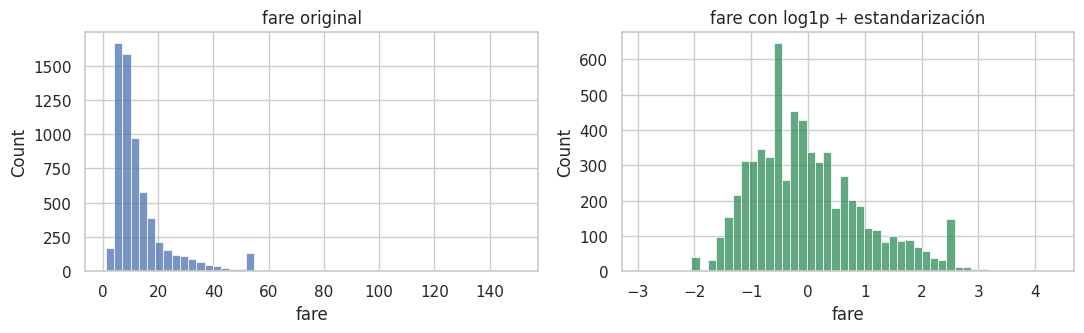

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
sns.histplot(df["fare"], bins=50, ax=axes[0]); axes[0].set_title("fare original")
sns.histplot(X_prep["fare"], bins=50, ax=axes[1], color="seagreen"); axes[1].set_title("fare con log1p + estandarización")
plt.tight_layout(); guardar_fig("03_escalado"); plt.show()

## 3. Reducción de dimensionalidad: PCA

Se aplica sobre las variables numéricas estandarizadas.

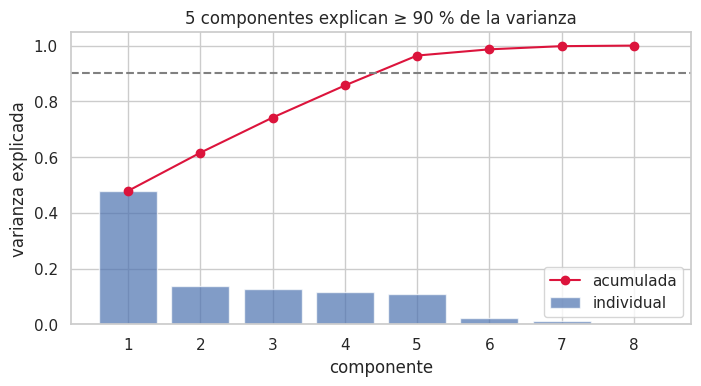

In [5]:
pca_cols = log_cols + num_cols
pca = PCA().fit(X_prep[pca_cols])
acum = np.cumsum(pca.explained_variance_ratio_)
n90 = int(np.argmax(acum >= 0.90) + 1)

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.bar(range(1, len(acum) + 1), pca.explained_variance_ratio_, alpha=0.7, label="individual")
ax.plot(range(1, len(acum) + 1), acum, "o-", c="crimson", label="acumulada")
ax.axhline(0.90, ls="--", c="gray")
ax.set_xlabel("componente"); ax.set_ylabel("varianza explicada"); ax.legend()
ax.set_title(f"{n90} componentes explican ≥ 90 % de la varianza")
guardar_fig("03_pca_scree"); plt.show()

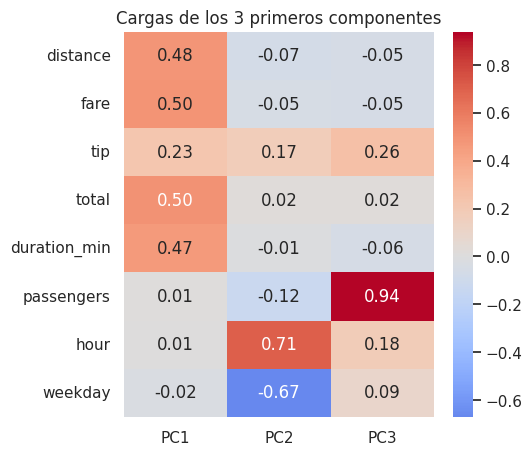

In [6]:
cargas = pd.DataFrame(pca.components_[:3].T, index=pca_cols, columns=["PC1", "PC2", "PC3"])
fig, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cargas, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Cargas de los 3 primeros componentes")
guardar_fig("03_pca_cargas"); plt.show()

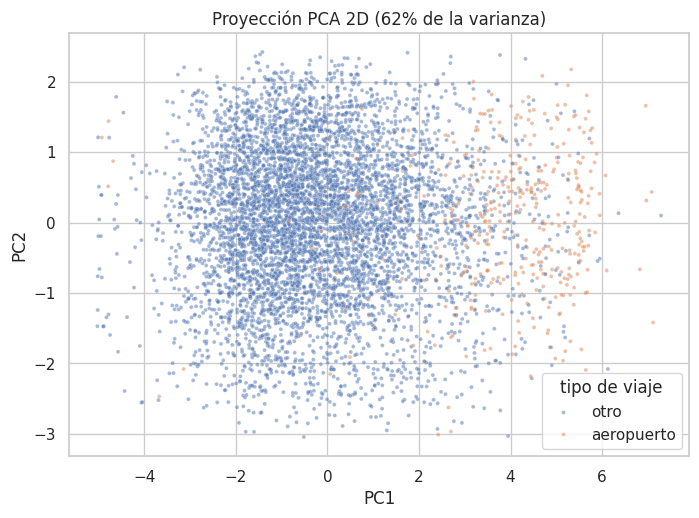

In [7]:
P = pd.DataFrame(pca.transform(X_prep[pca_cols])[:, :2], columns=["PC1", "PC2"])
P["tipo de viaje"] = df["airport"].map({True: "aeropuerto", False: "otro"})
fig, ax = plt.subplots(figsize=(8, 5.5))
sns.scatterplot(data=P, x="PC1", y="PC2", hue="tipo de viaje", s=8, alpha=0.5, ax=ax)
ax.set_title(f"Proyección PCA 2D ({acum[1]:.0%} de la varianza)")
guardar_fig("03_pca_proyeccion"); plt.show()

## Conclusiones

- Las categóricas quedaron codificadas con One-Hot y las numéricas en una misma escala: 29 columnas sin faltantes.
- **PC1 (48 % de la varianza)** agrupa distancia, tarifa, total, duración y propina: es el "tamaño del viaje" y confirma la redundancia vista en el EDA.
- **PC2** recoge hora y día de la semana, y **PC3** el número de pasajeros: son dimensiones independientes del costo.
- Con **5 componentes** se retiene el 96 % de la varianza de las 8 variables numéricas.
- En la proyección 2D los viajes a aeropuerto se ubican en el extremo derecho de PC1 (viajes largos y caros).

In [8]:
X_prep.to_csv(PROCESSED / "taxis_preprocesado.csv", index=False)
reducido = pd.concat([pd.DataFrame(PCA(n_components=n90).fit_transform(X_prep[pca_cols]),
                                   columns=[f"PC{i}" for i in range(1, n90 + 1)]),
                      X_prep.drop(columns=pca_cols)], axis=1)
reducido.to_csv(PROCESSED / "taxis_pca.csv", index=False)
print("Preprocesado:", X_prep.shape, "| Reducido:", reducido.shape, f"| varianza retenida: {acum[n90-1]:.1%}")

Preprocesado: (6433, 29) | Reducido: (6433, 26) | varianza retenida: 96.4%
